In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import cross_val_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")
print("Sprint 2 — Demand Forecasting Model")

Libraries loaded
Sprint 2 — Demand Forecasting Model


In [31]:
# Load data
df = pd.read_csv('../data/sbd_sales_data.csv')
df['date'] = pd.to_datetime(df['date'])

# Sort by SKU, warehouse, and date — this is critical for time series
# If data is not sorted correctly, lag features will be wrong
df = df.sort_values(['sku_id', 'warehouse', 'date']).reset_index(drop=True)

print(f"Rows loaded: {len(df):,}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Sorted by: sku_id, warehouse, date")
print("\nFirst 3 rows after sorting:")
df[['date','warehouse','sku_id','demand','is_promo']].head(3)

Rows loaded: 12,480
Date range: 2021-01-04 to 2023-12-25
Sorted by: sku_id, warehouse, date

First 3 rows after sorting:


,date,warehouse,sku_id,demand,is_promo
0,2021-01-04,Atlanta,DCB205_Battery,196,0
1,2021-01-11,Atlanta,DCB205_Battery,204,0
2,2021-01-18,Atlanta,DCB205_Battery,299,0


In [32]:
# Feature engineering
# We create new columns that the model learns from
# The model cannot learn from raw dates — we convert time into numbers

g = df.groupby(['sku_id', 'warehouse'])

# LAG FEATURES — what was demand in previous weeks
# shift(1) means look back 1 week
# shift(2) means look back 2 weeks  
# shift(4) means look back 4 weeks
df['demand_lag1'] = g['demand'].shift(1)
df['demand_lag2'] = g['demand'].shift(2)
df['demand_lag4'] = g['demand'].shift(4)

# ROLLING AVERAGES — smooth trend over last 4 and 8 weeks
df['rolling_mean_4'] = g['demand'].transform(
    lambda x: x.shift(1).rolling(4).mean())
df['rolling_mean_8'] = g['demand'].transform(
    lambda x: x.shift(1).rolling(8).mean())

# ROLLING STD — how volatile is this SKU
df['rolling_std_4'] = g['demand'].transform(
    lambda x: x.shift(1).rolling(4).std())

# Drop rows where lag features are null
# First few weeks per SKU have no history so we drop them
df = df.dropna().reset_index(drop=True)

print(f"Rows after feature engineering: {len(df):,}")
print(f"\nNew columns created:")
new_cols = ['demand_lag1','demand_lag2','demand_lag4',
            'rolling_mean_4','rolling_mean_8','rolling_std_4']
print(df[['sku_id','warehouse','date','demand'] + new_cols].head(3).to_string())

Rows after feature engineering: 11,840

New columns created:
           sku_id warehouse       date  demand  demand_lag1  demand_lag2  demand_lag4  rolling_mean_4  rolling_mean_8  rolling_std_4
0  DCB205_Battery   Atlanta 2021-03-01     287        329.0        355.0        269.0          307.25         271.750      41.604287
1  DCB205_Battery   Atlanta 2021-03-08     399        287.0        329.0        276.0          311.75         283.125      36.782016
2  DCB205_Battery   Atlanta 2021-03-15     516        399.0        287.0        355.0          342.50         307.500      46.943228


In [33]:
# Split data into training and testing
# CRITICAL RULE: never split time series randomly
# Always split by date — past = train, future = test
# If you split randomly the model sees future data during training
# and looks great but fails in real life

split_date = df['date'].max() - pd.Timedelta(weeks=8)

train = df[df['date'] <= split_date]
test  = df[df['date'] >  split_date]

# These are the columns the model learns from
FEATURES = ['week_of_year', 'year', 'is_promo',
            'demand_lag1', 'demand_lag2', 'demand_lag4',
            'rolling_mean_4', 'rolling_mean_8', 'rolling_std_4']

X_train = train[FEATURES]
y_train = train['demand']
X_test  = test[FEATURES]
y_test  = test['demand']

print(f"Split date: {split_date.date()}")
print(f"Train rows: {len(X_train):,} — {train['date'].min().date()} to {train['date'].max().date()}")
print(f"Test rows:  {len(X_test):,}  — {test['date'].min().date()} to {test['date'].max().date()}")
print(f"\nFeatures the model will learn from:")
for f in FEATURES:
    print(f"  {f}")
    

Split date: 2023-10-30
Train rows: 11,200 — 2021-03-01 to 2023-10-30
Test rows:  640  — 2023-11-06 to 2023-12-25

Features the model will learn from:
  week_of_year
  year
  is_promo
  demand_lag1
  demand_lag2
  demand_lag4
  rolling_mean_4
  rolling_mean_8
  rolling_std_4


In [34]:
# BASELINE MODEL — rolling 4 week average
# This is roughly what the Excel team does today
# We need to beat this by 15% to justify deploying ML

baseline_preds = test['rolling_mean_4'].values
baseline_mape = mean_absolute_percentage_error(y_test, baseline_preds) * 100
baseline_mae  = mean_absolute_error(y_test, baseline_preds)

print("=" * 45)
print("BASELINE MODEL — rolling 4 week average")
print("=" * 45)
print(f"MAPE: {baseline_mape:.1f}%")
print(f"MAE:  {baseline_mae:.1f} units")
print(f"\nThis means the Excel method is off by")
print(f"{baseline_mape:.1f}% on average per SKU per week")
print(f"Or about {baseline_mae:.0f} units wrong per prediction")

BASELINE MODEL — rolling 4 week average
MAPE: 21.1%
MAE:  52.0 units

This means the Excel method is off by
21.1% on average per SKU per week
Or about 52 units wrong per prediction


In [35]:
# XGBOOST MODEL
# n_estimators = how many trees to build (300 is a good start)
# learning_rate = how much each tree contributes (smaller = more careful)
# max_depth = how deep each tree goes (5 is standard)
# subsample = use 80% of data per tree (prevents overfitting)
# random_state = makes results reproducible every time you run

model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42,
    verbosity=0
)

print("Training XGBoost model...")
model.fit(X_train, y_train)
print("Training complete")

# Make predictions on test data
preds = model.predict(X_test)

# Demand cannot be negative — clip anything below 0 to 0
preds = np.maximum(preds, 0)

# Calculate accuracy
xgb_mape = mean_absolute_percentage_error(y_test, preds) * 100
xgb_mae  = mean_absolute_error(y_test, preds)

print("\n" + "=" * 45)
print("XGBOOST MODEL RESULTS")
print("=" * 45)
print(f"MAPE: {xgb_mape:.1f}%")
print(f"MAE:  {xgb_mae:.1f} units")
print(f"\nBaseline MAPE: {baseline_mape:.1f}%")
print(f"XGBoost MAPE: {xgb_mape:.1f}%")
improvement = baseline_mape - xgb_mape
print(f"Improvement:  {improvement:.1f} percentage points")
print(f"\nTarget was 15% improvement = below {baseline_mape*0.85:.1f}%")
if xgb_mape < baseline_mape * 0.85:
    print("RESULT: TARGET MET — model is ready for deployment")
else:
    print("RESULT: TARGET NOT MET — needs improvement")
    

Training XGBoost model...
Training complete

XGBOOST MODEL RESULTS
MAPE: 12.8%
MAE:  33.8 units

Baseline MAPE: 21.1%
XGBoost MAPE: 12.8%
Improvement:  8.3 percentage points

Target was 15% improvement = below 17.9%
RESULT: TARGET MET — model is ready for deployment


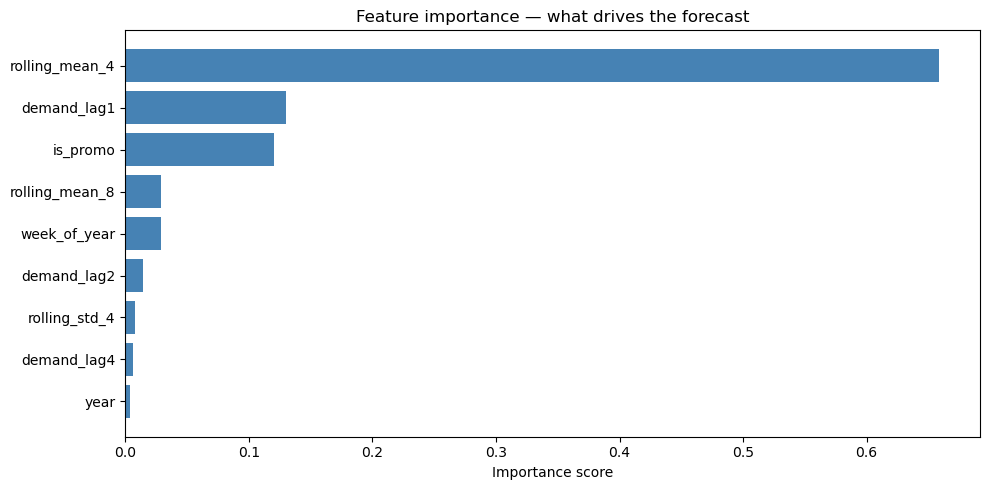

Feature importance ranking:
  rolling_mean_4: 0.659 — 65.9% of model decisions
  demand_lag1: 0.130 — 13.0% of model decisions
  is_promo: 0.120 — 12.0% of model decisions
  rolling_mean_8: 0.029 — 2.9% of model decisions
  week_of_year: 0.029 — 2.9% of model decisions
  demand_lag2: 0.015 — 1.5% of model decisions
  rolling_std_4: 0.008 — 0.8% of model decisions
  demand_lag4: 0.006 — 0.6% of model decisions
  year: 0.004 — 0.4% of model decisions


In [36]:
# Feature importance — what did the model learn from most
fi = pd.Series(model.feature_importances_, index=FEATURES)
fi = fi.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(fi.index, fi.values, color='steelblue')
plt.title('Feature importance — what drives the forecast')
plt.xlabel('Importance score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/06_feature_importance.png', dpi=150)
plt.show()

print("Feature importance ranking:")
for feat, imp in fi.items():
    print(f"  {feat}: {imp:.3f} — {imp/fi.sum()*100:.1f}% of model decisions")

In [37]:
import pickle
import os

# Save the trained model to the models folder
os.makedirs('../models', exist_ok=True)

with open('../models/xgb_demand_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save the feature list — ML Engineer needs this for deployment
with open('../models/feature_list.txt', 'w') as f:
    f.write('\n'.join(FEATURES))

# Save accuracy results
with open('../models/model_results.txt', 'w') as f:
    f.write(f"Baseline MAPE: {baseline_mape:.1f}%\n")
    f.write(f"XGBoost MAPE: {xgb_mape:.1f}%\n")
    f.write(f"Improvement: {baseline_mape - xgb_mape:.1f} percentage points\n")
    f.write(f"MAE: {xgb_mae:.1f} units\n")

print("Model saved to models/xgb_demand_model.pkl")
print("Feature list saved to models/feature_list.txt")
print("Results saved to models/model_results.txt")
print("\nSprint 2 complete.")
print("Hand off to ML Engineer:")
print(f"  Model file: models/xgb_demand_model.pkl")
print(f"  Features:   {FEATURES}")
print(f"  MAPE:       {xgb_mape:.1f}%")
print(f"  Retrain:    monthly on fresh data")

Model saved to models/xgb_demand_model.pkl
Feature list saved to models/feature_list.txt
Results saved to models/model_results.txt

Sprint 2 complete.
Hand off to ML Engineer:
  Model file: models/xgb_demand_model.pkl
  Features:   ['week_of_year', 'year', 'is_promo', 'demand_lag1', 'demand_lag2', 'demand_lag4', 'rolling_mean_4', 'rolling_mean_8', 'rolling_std_4']
  MAPE:       12.8%
  Retrain:    monthly on fresh data
